In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
housing = fetch_california_housing()

data = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

data['Price'] = housing.target

data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = data[['AveRooms']].values
y = data['Price'].values

print(X.shape)
print(y.shape)

(20640, 1)
(20640,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
w = 0
b = 0

cost_history=[]

learning_rate = 0.01
epochs = 1000

n = len(X_train_scaled)


for i in range(epochs):

    y_pred = w * X_train_scaled.flatten() + b
    
    dw = (1/n) * np.sum(
        (y_pred-y_train)*X_train_scaled.flatten()
    )
    
    db = (1/n)*np.sum(y_pred-y_train)

    w = w-learning_rate*dw
    b = b-learning_rate*db


    cost = (1/(2*n))*np.sum(
        (y_pred-y_train)**2
    )

    cost_history.append(cost)


    if i%100==0:
        print(f"Epoch {i}, Cost = {cost:.4f}")

Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [7]:
y_pred_gd = w*X_test_scaled.flatten()+b


print("Gradient Descent")
print("----------------")
print("Weight:",w)
print("Bias:",b)

print("MSE:",
      mean_squared_error(y_test,y_pred_gd))

print("R2 Score:",
      r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.292327655590046
R2 Score: 0.013798228607320828


In [8]:
X_train_ne = np.c_[
    np.ones((len(X_train),1)),
    X_train
]

X_test_ne = np.c_[
    np.ones((len(X_test),1)),
    X_test
]


theta = np.linalg.inv(
    X_train_ne.T @ X_train_ne
) @ X_train_ne.T @ y_train


y_pred_ne = X_test_ne @ theta


print("\nNormal Equation")
print("-----------------")

print("Intercept:",theta[0])
print("Slope:",theta[1])

print("MSE:",
      mean_squared_error(y_test,y_pred_ne))

print("R2 Score:",
      r2_score(y_test,y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968384
Slope: 0.07675558963126795
MSE: 1.2923314440807303
R2 Score: 0.013795337532284568


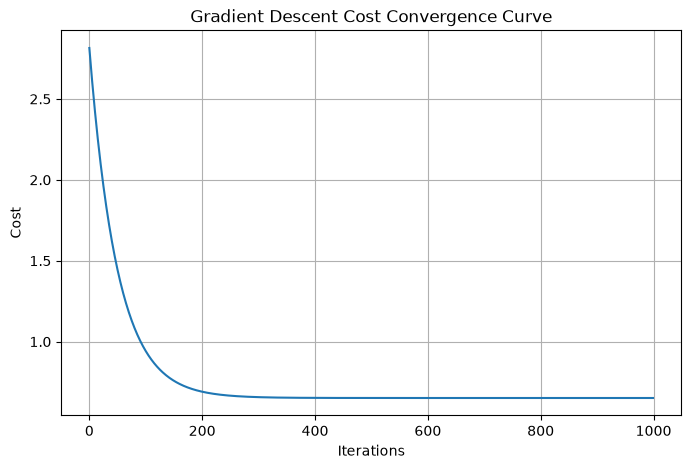

In [9]:
plt.figure(figsize=(8,5))

plt.plot(cost_history)

plt.title(
"Gradient Descent Cost Convergence Curve"
)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.grid(True)

plt.show()

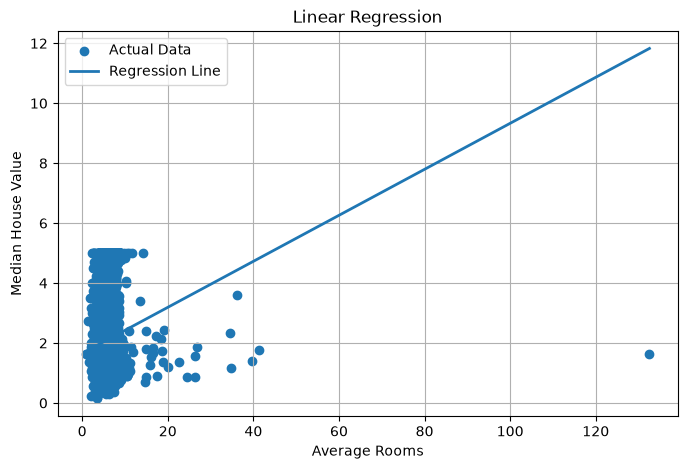

In [10]:
index=np.argsort(X_test.flatten())


plt.figure(figsize=(8,5))


plt.scatter(
    X_test,
    y_test,
    label="Actual Data"
)


plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    linewidth=2,
    label="Regression Line"
)


plt.title("Linear Regression")

plt.xlabel("Average Rooms")

plt.ylabel("Median House Value")

plt.legend()

plt.grid(True)

plt.show()